# Candidate-Site Environmental Screening

## Goal

Convert high-priority mapped parking opportunities into a preliminary candidate-site shortlist, screen them against FEMA flood hazards and National Wetlands Inventory features, and flag intersections with PAD-US protected areas for manual review.

> These are screening points, not verified parcels. Ownership, zoning, parking layout, utility capacity, easements, permits, and construction feasibility still require site-level review.

## Context & Methods

### Screening rules

- Candidate source: mapped OpenStreetMap parking opportunities inside the highest Level 2 suitability quartile.
- Hard exclusions: FEMA Special Flood Hazard Area or mapped NWI wetland intersection.
- Review flag: PAD-US intersection. This is not an automatic exclusion because an existing paved public lot within a park may still merit agency review.
- Road access proxy: a mapped parking facility is assumed to have vehicle access, but driveway and circulation conditions remain unverified.

In [1]:
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import Request, urlopen
import json

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path(r"C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability")
ENV_DIR = PROJECT_ROOT / "data" / "raw" / "environmental"
SPATIAL_DIR = PROJECT_ROOT / "outputs" / "spatial"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
MAP_DIR = PROJECT_ROOT / "maps"
for folder in [ENV_DIR, SPATIAL_DIR, TABLE_DIR, MAP_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

opportunity_path = SPATIAL_DIR / "level2_destination_opportunities.gpkg"
suitability_path = SPATIAL_DIR / "level2_destination_suitability.gpkg"
if not opportunity_path.exists() or not suitability_path.exists():
    raise FileNotFoundError("Run notebook 07 before environmental candidate screening.")

opportunities = gpd.read_file(opportunity_path, layer="destinations").to_crs("EPSG:4326")
suitability = gpd.read_file(suitability_path, layer="level2_suitability").to_crs("EPSG:4326")

FEMA_LAYER = "https://hazards.fema.gov/arcgis/rest/services/public/NFHL/MapServer/28"
NWI_LAYER = "https://fwspublicservices.wim.usgs.gov/wetlandsmapservice/rest/services/Wetlands/MapServer/0"
PADUS_ITEM = "98fce3fb0c8241ce8847e9f7d0d212e9"
ARCGIS_ITEM_ENDPOINT = f"https://www.arcgis.com/sharing/rest/content/items/{PADUS_ITEM}"


## Data

### 1. Select mapped parking opportunities in high-suitability areas

In [2]:
parking = opportunities.loc[opportunities["destination_type"] == "Parking"].copy()
parking_with_area = gpd.sjoin(
    parking,
    suitability[["GEOID", "county_name", "level2_suitability_score", "level2_priority", "geometry"]],
    how="inner", predicate="within",
).drop(columns=["index_right"])

candidates = parking_with_area.loc[
    parking_with_area["level2_priority"] == "High relative priority"
].copy()
candidates = candidates.drop_duplicates(subset=["osm_type", "osm_id"]).reset_index(drop=True)
candidates["candidate_id"] = [f"L2-{index:04d}" for index in range(1, len(candidates) + 1)]

assert not candidates.empty, "No parking opportunities intersected high-priority areas."
print(f"Parking opportunities reviewed: {len(parking):,}")
print(f"Candidates entering environmental screening: {len(candidates):,}")

Parking opportunities reviewed: 41
Candidates entering environmental screening: 27


### 2. Query official environmental services at each candidate point

The query results are cached locally so rerunning later cells does not repeat every web request.

In [3]:
def read_json(url, parameters):
    request = Request(f"{url}?{urlencode(parameters)}", headers={"User-Agent": "GIS-Portfolio-EV-Suitability/1.0"})
    with urlopen(request, timeout=120) as response:
        payload = json.load(response)
    if "error" in payload:
        raise RuntimeError(f"ArcGIS service error: {payload['error']}")
    return payload

def point_intersection_count(layer_url, longitude, latitude, where="1=1"):
    payload = read_json(
        f"{layer_url}/query",
        {
            "where": where, "geometry": f"{longitude},{latitude}",
            "geometryType": "esriGeometryPoint", "inSR": "4326",
            "spatialRel": "esriSpatialRelIntersects", "returnCountOnly": "true", "f": "json",
        },
    )
    return int(payload.get("count", 0))

padus_item_metadata = read_json(ARCGIS_ITEM_ENDPOINT, {"f": "json"})
PADUS_LAYER = padus_item_metadata.get("url")
if not PADUS_LAYER:
    raise RuntimeError("The PAD-US ArcGIS item did not provide a feature-service URL.")
if not PADUS_LAYER.rstrip("/").split("/")[-1].isdigit():
    PADUS_LAYER = PADUS_LAYER.rstrip("/") + "/0"

cache_path = ENV_DIR / "candidate_environmental_screening.csv"
if cache_path.exists():
    screening = pd.read_csv(cache_path)
else:
    screening_records = []
    for row in candidates.itertuples():
        longitude, latitude = row.geometry.x, row.geometry.y
        screening_records.append({
            "candidate_id": row.candidate_id,
            "fema_sfha_count": point_intersection_count(FEMA_LAYER, longitude, latitude, "SFHA_TF='T'"),
            "nwi_wetland_count": point_intersection_count(NWI_LAYER, longitude, latitude),
            "padus_intersection_count": point_intersection_count(PADUS_LAYER, longitude, latitude),
        })
    screening = pd.DataFrame(screening_records)
    screening.to_csv(cache_path, index=False)

print("Environmental service results:", cache_path)
display(screening.head())

Environmental service results: C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability\data\raw\environmental\candidate_environmental_screening.csv


,candidate_id,fema_sfha_count,nwi_wetland_count,padus_intersection_count
0,L2-0001,0,0,1
1,L2-0002,0,0,1
2,L2-0003,0,0,1
3,L2-0004,0,0,1
4,L2-0005,0,0,0


## Results

### 3. Apply exclusions, review flags, and shortlist ranking

In [4]:
screened = candidates.merge(screening, on="candidate_id", validate="one_to_one")
screened["flood_exclusion"] = screened["fema_sfha_count"] > 0
screened["wetland_exclusion"] = screened["nwi_wetland_count"] > 0
screened["protected_land_review"] = screened["padus_intersection_count"] > 0
screened["environmentally_eligible"] = ~(
    screened["flood_exclusion"] | screened["wetland_exclusion"]
)

# PAD-US is a review flag rather than a hard exclusion; apply a modest ranking penalty.
screened["screened_site_score"] = (
    screened["level2_suitability_score"] -
    np.where(screened["protected_land_review"], 10, 0)
)
eligible = screened.loc[screened["environmentally_eligible"]].copy()
assert not eligible.empty, "All candidates were excluded; inspect source coverage and screening rules."
eligible = eligible.sort_values(
    ["screened_site_score", "level2_suitability_score"], ascending=False
).reset_index(drop=True)
eligible["shortlist_rank"] = eligible.index + 1

screened.to_file(SPATIAL_DIR / "level2_candidate_environmental_screening.gpkg", layer="screened_candidates", driver="GPKG")
eligible.head(50).to_file(SPATIAL_DIR / "level2_candidate_shortlist.gpkg", layer="shortlist", driver="GPKG")

table_fields = [
    "shortlist_rank", "candidate_id", "name", "county_name", "access", "capacity",
    "level2_suitability_score", "protected_land_review", "screened_site_score",
    "osm_type", "osm_id",
]
eligible.head(50)[table_fields].to_csv(TABLE_DIR / "level2_candidate_shortlist.csv", index=False)

summary = pd.Series({
    "candidates_screened": len(screened),
    "excluded_flood": int(screened["flood_exclusion"].sum()),
    "excluded_wetland": int(screened["wetland_exclusion"].sum()),
    "protected_land_review": int(screened["protected_land_review"].sum()),
    "environmentally_eligible": len(eligible),
})
display(summary.to_frame("count"))
display(eligible.head(20)[table_fields].round(2))

,count
candidates_screened,27
excluded_flood,1
excluded_wetland,0
protected_land_review,10
environmentally_eligible,26


,shortlist_rank,candidate_id,name,county_name,access,capacity,level2_suitability_score,protected_land_review,screened_site_score,osm_type,osm_id
0,1,L2-0020,NaN,Clarke,NaN,NaN,72.44,False,72.44,node,12883951935
1,2,L2-0021,NaN,Clarke,NaN,NaN,72.44,False,72.44,node,12883951936
2,3,L2-0015,NaN,Clarke,NaN,NaN,70.20,False,70.20,node,10909795503
3,4,L2-0016,NaN,Clarke,NaN,NaN,70.20,False,70.20,node,10909799519
4,5,L2-0024,NaN,Clarke,NaN,NaN,70.20,False,70.20,node,13712403911
5,6,L2-0025,NaN,Clarke,NaN,NaN,70.20,False,70.20,node,13712403912
6,7,L2-0014,NaN,Clarke,NaN,NaN,69.34,False,69.34,node,8815849460
7,8,L2-0027,NaN,Barrow,customers,5,67.73,False,67.73,node,13894885441
8,9,L2-0010,NaN,Clarke,NaN,NaN,74.64,True,64.64,node,2533894804
9,10,L2-0011,NaN,Clarke,NaN,NaN,74.64,True,64.64,node,2533894805


### 4. Map candidate screening outcomes

C:\Users\cason\miniconda3\envs\myenvironment\Lib\site-packages\geopandas\plotting.py:305: UserWarning: You passed an edgecolor/edgecolors ('#30343B') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  collection = ax.scatter(x, y, vmin=vmin, vmax=vmax, cmap=cmap, **kwargs)


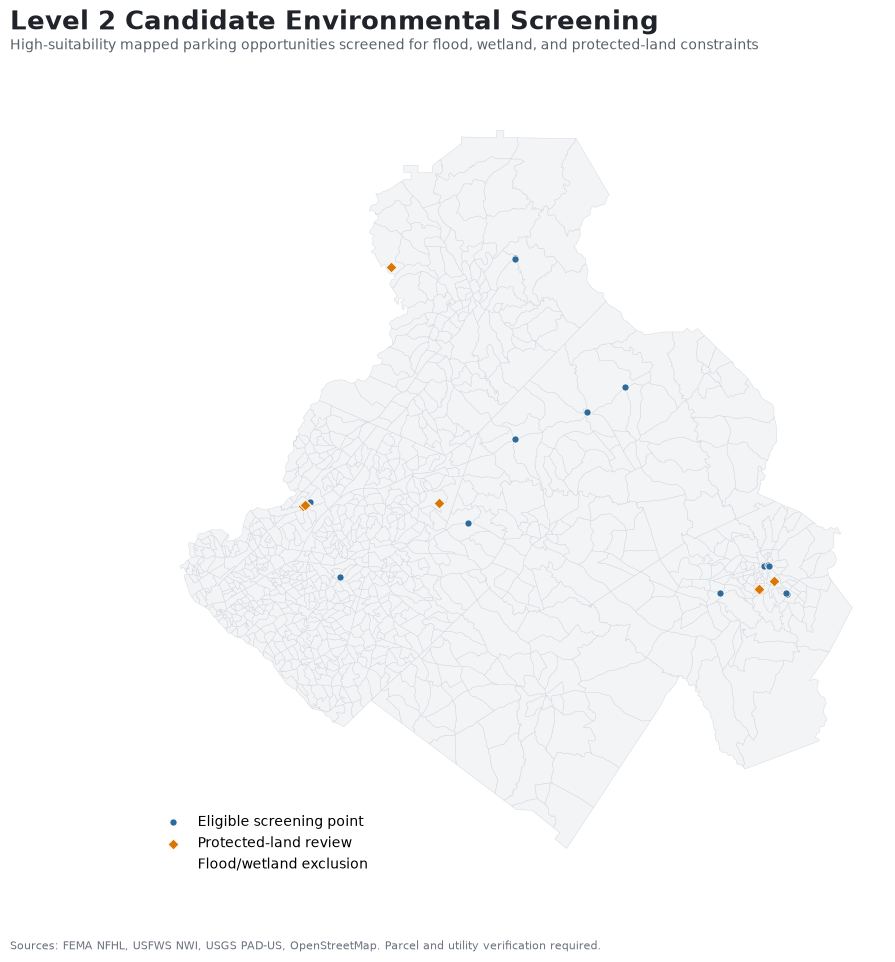

Saved: C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability\maps\level2_candidate_environmental_screening.png


In [5]:
fig, ax = plt.subplots(figsize=(11, 10), facecolor="white")
suitability.plot(ax=ax, color="#F3F4F6", edgecolor="#D1D5DB", linewidth=0.3)

excluded = screened.loc[~screened["environmentally_eligible"]]
review = screened.loc[screened["environmentally_eligible"] & screened["protected_land_review"]]
clear = screened.loc[screened["environmentally_eligible"] & ~screened["protected_land_review"]]

if not clear.empty:
    clear.plot(ax=ax, color="#2F6B9A", marker="o", markersize=26, edgecolor="white", linewidth=0.5, label="Eligible screening point")
if not review.empty:
    review.plot(ax=ax, color="#D97706", marker="D", markersize=30, edgecolor="white", linewidth=0.5, label="Protected-land review")
if not excluded.empty:
    excluded.plot(ax=ax, facecolor="none", edgecolor="#30343B", marker="x", markersize=34, linewidth=1.0, label="Flood/wetland exclusion")

fig.suptitle("Level 2 Candidate Environmental Screening", x=0.04, y=0.965, ha="left", fontsize=19, weight="bold", color="#20242A")
fig.text(0.04, 0.925, "High-suitability mapped parking opportunities screened for flood, wetland, and protected-land constraints", ha="left", fontsize=10, color="#59616B")
ax.legend(frameon=False, loc="lower left")
ax.set_axis_off()
fig.text(0.04, 0.025, "Sources: FEMA NFHL, USFWS NWI, USGS PAD-US, OpenStreetMap. Parcel and utility verification required.", fontsize=8, color="#6B7280")
fig.subplots_adjust(left=0.03, right=0.97, top=0.88, bottom=0.09)

map_path = MAP_DIR / "level2_candidate_environmental_screening.png"
fig.savefig(map_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", map_path)

## Validation

In [6]:
assert candidates["candidate_id"].is_unique
assert screening["candidate_id"].is_unique
assert len(screened) == len(candidates), "Environmental results did not reconcile one-to-one with candidates."
assert not (eligible["flood_exclusion"] | eligible["wetland_exclusion"]).any()
assert screened[["fema_sfha_count", "nwi_wetland_count", "padus_intersection_count"]].notna().all().all()

expected_outputs = [
    SPATIAL_DIR / "level2_candidate_environmental_screening.gpkg",
    SPATIAL_DIR / "level2_candidate_shortlist.gpkg",
    TABLE_DIR / "level2_candidate_shortlist.csv",
    MAP_DIR / "level2_candidate_environmental_screening.png",
]
assert all(path.exists() for path in expected_outputs)

print("All candidate-grain, exclusion, reconciliation, and output checks passed.")
print("Validation status: Needs parcel, ownership, zoning, utility, and field verification before recommendation.")

All candidate-grain, exclusion, reconciliation, and output checks passed.
Validation status: Needs parcel, ownership, zoning, utility, and field verification before recommendation.


## Next Steps

Estimate initial and expansion port counts for shortlisted Level 2 and DC-fast sites under current, moderate-adoption, and high-adoption scenarios.